# TCN Groundwater Level Forecasting


#Install and Import Libraries

In [ ]:
!pip install keras-tcn keras-tuner

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import joblib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tcn import TCN
import keras_tuner as kt
import os
import random

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


print('TensorFlow version:', tf.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 4.6 MB/s eta 0:00:00
TensorFlow version: 2.19.0


# EDA and Data Preparation for TCN

## Load the Raw Preprocessed Data


In [ ]:
#import the data and set the date to be the index
train_df = pd.read_csv('uk_train.csv',    index_col='date', parse_dates=True)
val_df   = pd.read_csv('uk_validate.csv', index_col='date', parse_dates=True)
test_df  = pd.read_csv('uk_test.csv',     index_col='date', parse_dates=True)

print(f'Train:      {train_df.shape}  | {train_df.index[0]} -> {train_df.index[-1]}')
print(f'Validation: {val_df.shape}   | {val_df.index[0]} -> {val_df.index[-1]}')
print(f'Test:       {test_df.shape}   | {test_df.index[0]} -> {test_df.index[-1]}')
print('\nColumns:', train_df.columns.tolist())
print('\nSample of raw training data (first 3 rows):')
print(train_df.head(3))

# Verify no missing values (should be zero per Section 3.2.3)
assert train_df.isnull().sum().sum() == 0, 'Missing values found in train!'
assert val_df.isnull().sum().sum()   == 0, 'Missing values found in validation!'
assert test_df.isnull().sum().sum()  == 0, 'Missing values found in test!'
print('\n✓ No missing values detected across all splits.')


Train:      (766, 4)  | 1944-01-01 00:00:00 -> 2007-10-01 00:00:00
Validation: (96, 4)   | 2007-11-01 00:00:00 -> 2015-10-01 00:00:00
Test:       (96, 4)   | 2015-11-01 00:00:00 -> 2023-10-01 00:00:00

Columns: ['water_level', 'temperature', 'precipitation', 'wind_speed']

Sample of raw training data (first 3 rows):
            water_level  temperature  precipitation  wind_speed
date                                                           
1944-01-01    48.541667     5.953366     117.599999   19.952928
1944-02-01    53.208056     3.432379      46.599999   14.308090
1944-03-01    52.452436     4.457599      14.600001   10.615601

✓ No missing values detected across all splits.


## Min-Max Normalisation
one for the features and one fro the target


In [ ]:
FEATURES = ['water_level', 'temperature', 'precipitation', 'wind_speed']
TARGET    = 'water_level'

# Fit both scalers on training data ONLY
scaler_features = MinMaxScaler()
scaler_target   = MinMaxScaler()

scaler_features.fit(train_df[FEATURES])   # All 4 features — training only
scaler_target.fit(train_df[[TARGET]])      # water_level only — for inverse transform

# Transform all three splits using training-fitted scalers
train_arr = scaler_features.transform(train_df[FEATURES])
val_arr   = scaler_features.transform(val_df[FEATURES])
test_arr  = scaler_features.transform(test_df[FEATURES])


print(f'Normalised array shapes:')
print(f'  Train: {train_arr.shape}, Val: {val_arr.shape}, Test: {test_arr.shape}')
print('\nPost-normalisation range check:')
print('Training values should be within [0,1]; validation/test may fall outside this range if future values exceed the training min/max.')

for i, col in enumerate(FEATURES):
    t_min, t_max = train_arr[:, i].min(), train_arr[:, i].max()
    v_min, v_max = val_arr[:, i].min(),   val_arr[:, i].max()
    s_min, s_max = test_arr[:, i].min(),  test_arr[:, i].max()

    print(f'  {col:20s} | train [{t_min:.3f}, {t_max:.3f}] '
          f'| val [{v_min:.3f}, {v_max:.3f}] '
          f'| test [{s_min:.3f}, {s_max:.3f}]')

Normalised array shapes:
  Train: (766, 4), Val: (96, 4), Test: (96, 4)

Post-normalisation range check:
Training values should be within [0,1]; validation/test may fall outside this range if future values exceed the training min/max.
  water_level          | train [0.000, 1.000] | val [0.596, 0.982] | test [0.607, 0.924]
  temperature          | train [0.000, 1.000] | val [0.111, 0.966] | test [0.259, 0.971]
  precipitation        | train [0.000, 1.000] | val [0.028, 1.000] | test [0.053, 1.000]
  wind_speed           | train [0.000, 1.000] | val [0.057, 0.740] | test [0.025, 0.781]


##  Sequence Generation


- `LOOKBACK = 24` months
- `HORIZON = 1` month — single-step-ahead forecasting


In [ ]:
LOOKBACK   = 24   # Same as LSTM (Section 3.6.2)
HORIZON    = 1    # Single-step-ahead
N_FEATURES = len(FEATURES)

def create_sequences(data, lookback=24, horizon=1):
    """
    Convert a 2D array (T, n_features) into supervised 3D sequences.
    Returns:
        X: shape (samples, lookback, n_features)
        y: shape (samples,)
    """
    X, y = [], []
    for i in range(lookback, len(data) - horizon + 1):
        X.append(data[i - lookback : i, :])       # All features for window
        y.append(data[i + horizon - 1, 0])         # water_level column (index 0)
    return np.array(X), np.array(y)


# Apply boundary buffer

val_buffered  = np.vstack([train_arr[-LOOKBACK:], val_arr])
test_buffered = np.vstack([val_arr[-LOOKBACK:],   test_arr])
# this would not cause data leckage because the model is already trained on those data added, but we add them because we need it to learn from it.
X_train, y_train = create_sequences(train_arr,     LOOKBACK, HORIZON)
X_val,   y_val   = create_sequences(val_buffered,  LOOKBACK, HORIZON)
X_test,  y_test  = create_sequences(test_buffered, LOOKBACK, HORIZON)

print(f'Sequence shapes:')
print(f'  X_train: {X_train.shape}  | y_train: {y_train.shape}')
print(f'  X_val:   {X_val.shape}    | y_val:   {y_val.shape}')
print(f'  X_test:  {X_test.shape}   | y_test:  {y_test.shape}')
# Expected: X shapes -> (samples, 24, 4);  y shapes -> (samples,)

Sequence shapes:
  X_train: (742, 24, 4)  | y_train: (742,)
  X_val:   (96, 24, 4)    | y_val:   (96,)
  X_test:  (96, 24, 4)   | y_test:  (96,)


##  Receptive Field Calculation

RF formula for keras-tcn:  
`RF = 1 + 2 × (kernel_size − 1) × nb_stacks × Σ(dilations)`



In [ ]:
def compute_receptive_field(kernel_size, dilations, nb_stacks=1):
    return 1 + 2 * (kernel_size - 1) * nb_stacks * sum(dilations)

# Check for baseline settings
# those values are resonable for a baseline , I will optmize them in later steps
baseline_rf = compute_receptive_field(kernel_size=2, dilations=[1, 2, 4, 8, 16], nb_stacks=1)
print(f'Baseline TCN receptive field: {baseline_rf} months (LOOKBACK = {LOOKBACK})')
print(f'  -> {"✓ RF exceeds lookback" if baseline_rf >= LOOKBACK else "✗ WARNING: RF < LOOKBACK"}')

Baseline TCN receptive field: 63 months (LOOKBACK = 24)
  -> ✓ RF exceeds lookback


# Build and Train the Baseline TCN Model

### Build baseline TCN model as a function


In [ ]:
def build_baseline_tcn(input_shape):
    inputs = keras.Input(shape=input_shape)

    # building the TCN layer where it learns from the sequences.
    x = TCN(
        nb_filters=64,
        kernel_size=2,
        nb_stacks=1,
        dilations=[1, 2, 4, 8, 16],
        padding='causal',
        use_skip_connections=True,
        dropout_rate=0.2,
        return_sequences=False,
        name='tcn_baseline'
    )(inputs)

    outputs = layers.Dense(1, name='output')(x) # this is the step that it transform the produced vector into an actuall prediction

    model = keras.Model(inputs, outputs, name='Baseline_TCN') # This wires the input and output together into one complete model object.

  # telling the model how to learn
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),# adjusts the model's internal weights after each batch to reduce the loss.
        loss='mse',#  Mean Squared Error. This is what the model is trying to minimise during training.
        metrics=['mae'] # Mean Absolute Error is tracked separately just for monitoring purposes during training.
    )

    return model

### Train the baseline model

In [ ]:
input_shape  = (LOOKBACK, N_FEATURES)   # building model architecture  (24, 4)
baseline_tcn = build_baseline_tcn(input_shape)
baseline_tcn.summary()

baseline_callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),# after every epoch, it checks whether the validation loss improved. If it has not improved for 20 consecutive epochs, training stops.
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1) #  if validation loss has not improved for 10 epochs, it halves the learning rate (factor=0.5)
]

baseline_history = baseline_tcn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),# after every epoch, the model is tested on the validation set without learning from it.
    epochs=200,# number of rounds it will run
    batch_size=32,#  shows 32 at a time, calculates the loss
    callbacks=baseline_callbacks,
    verbose=1,
    shuffle=False
)

print(f'\nBaseline TCN stopped at epoch: {len(baseline_history.history["loss"])}') # which epoch early stopping triggered at

Model: "Baseline_TCN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 24, 4)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_baseline (TCN)              │ (None, 64)             │        75,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,265 (294.00 KB)

 Trainable params: 75,265 (294.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 17s 157ms/step - loss: 30.7704 - mae: 3.8200 - val_loss: 1.0099 - val_mae: 0.9117 - learning_rate: 0.0010
Epoch 2/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 2.2460 - mae: 1.1932 - val_loss: 0.4212 - val_mae: 0.5588 - learning_rate: 0.0010
Epoch 3/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 1.4999 - mae: 0.9752 - val_loss: 0.2832 - val_mae: 0.4586 - learning_rate: 0.0010
Epoch 4/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 1.0036 - mae: 0.7999 - val_loss: 0.3664 - val_mae: 0.5522 - learning_rate: 0.0010
Epoch 5/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.8105 - mae: 0.7074 - val_loss: 0.2935 - val_mae: 0.4823 - learning_rate: 0.0010
Epoch 6/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.7683 - mae: 0.6832 - val_loss: 0.1509 - val_mae: 0.3134 - learning_rate: 0.0010
Epoch 7/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.6542 - mae: 0.6436 - val_loss: 0.0980 - val_mae: 0.2527 - learning_rate: 0.0010
Epo

### Plot Baseline Training


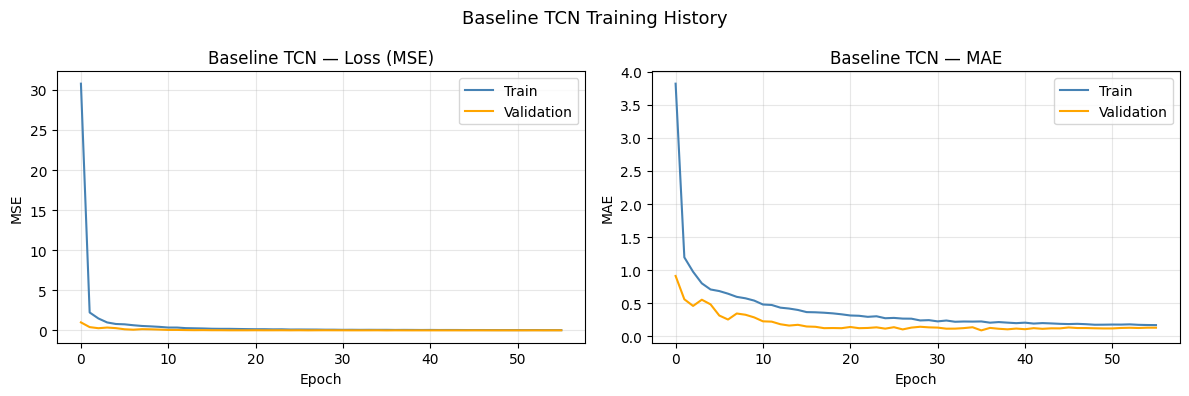

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(baseline_history.history['loss'],     label='Train',      color='steelblue')
axes[0].plot(baseline_history.history['val_loss'], label='Validation', color='orange')
axes[0].set_title('Baseline TCN — Loss (MSE)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(baseline_history.history['mae'],     label='Train',      color='steelblue')
axes[1].plot(baseline_history.history['val_mae'], label='Validation', color='orange')
axes[1].set_title('Baseline TCN — MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Baseline TCN Training History', fontsize=13)
plt.tight_layout()
plt.savefig('tcn_baseline_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

converges

# Bayesian Hyperparameter Optimisation


**Search space:**
- `nb_filters`: [32, 64, 128] — number of learned convolutional filters
- `kernel_size`: [2, 3, 4] — convolution window width
- `dilations`: 3 preset sets — controls receptive field
- `dropout_rate`: [0.1, 0.2, 0.3] — regularisation strength
- `learning_rate`: continuous log-scale [1e-4, 1e-3]

In [ ]:
# ── Expanded Dilation Presets ─────────────────────────────────────────────
# All guarantee RF ≥ LOOKBACK (24) with kernel_size ≥ 2
DILATION_OPTIONS = {
    0: [1, 2, 4, 8],           # RF = 31  (k=2), shorter memory
    1: [1, 2, 4, 8, 16],       # RF = 63  (k=2), moderate memory
    2: [1, 2, 4, 8, 16, 32],   # RF = 127 (k=2), long memory
}

def build_tunable_tcn(hp):
    nb_filters    = hp.Choice('nb_filters',   values=[16, 32, 64, 128])
    kernel_size   = hp.Choice('kernel_size',  values=[2, 3, 4])
    dilation_idx  = hp.Choice('dilation_set', values=[0, 1, 2])
    nb_stacks     = hp.Choice('nb_stacks',    values=[1, 2])
    dropout_rate  = hp.Float('dropout_rate',  min_value=0.1, max_value=0.4, step=0.1)
    learning_rate = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')

    dilations = DILATION_OPTIONS[dilation_idx]

    inputs = keras.Input(shape=(LOOKBACK, N_FEATURES))
    x = TCN(
        nb_filters=nb_filters,
        kernel_size=kernel_size,
        nb_stacks=nb_stacks,
        dilations=dilations,
        padding='causal',
        use_skip_connections=True,
        dropout_rate=dropout_rate,
        return_sequences=False,
        name='tcn_tuned'
    )(inputs)
    outputs = layers.Dense(1, name='output')(x)
    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )
    return model


tuner = kt.BayesianOptimization(
    build_tunable_tcn,
    objective='val_loss',
    max_trials=50,
    seed=42,
    directory='tcn_tuner_dir',
    project_name='tcn_gwl_search_v2',
    overwrite=True
)

tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)],
    verbose=1,
    shuffle=False
)

tuner.results_summary()

Trial 50 Complete [00h 01m 38s]
val_loss: 1.957887053489685

Best val_loss So Far: 0.0036447206512093544
Total elapsed time: 01h 11m 28s
Results summary
Results in tcn_tuner_dir/tcn_gwl_search_v2
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 46 summary
Hyperparameters:
nb_filters: 128
kernel_size: 4
dilation_set: 2
nb_stacks: 1
dropout_rate: 0.1
learning_rate: 0.01
Score: 0.0036447206512093544

Trial 30 summary
Hyperparameters:
nb_filters: 32
kernel_size: 4
dilation_set: 1
nb_stacks: 1
dropout_rate: 0.1
learning_rate: 0.00123059565218843
Score: 0.0038204838056117296

Trial 12 summary
Hyperparameters:
nb_filters: 16
kernel_size: 4
dilation_set: 2
nb_stacks: 1
dropout_rate: 0.30000000000000004
learning_rate: 0.0071223894490449685
Score: 0.0040496885776519775

Trial 40 summary
Hyperparameters:
nb_filters: 16
kernel_size: 2
dilation_set: 0
nb_stacks: 1
dropout_rate: 0.1
learning_rate: 0.01
Score: 0.004073710646480322

Trial 48 summary
Hyperparameters:
nb_filters

## Retrieve and Inspect Best Hyperparameters


In [ ]:
best_hps       = tuner.get_best_hyperparameters(num_trials=1)[0]
best_dilations = DILATION_OPTIONS[best_hps.get('dilation_set')]
best_rf        = compute_receptive_field(best_hps.get('kernel_size'), best_dilations)

print('=' * 50)
print('  BEST TCN HYPERPARAMETERS')
print('=' * 50)
print(f'  nb_filters:      {best_hps.get("nb_filters")}')
print(f'  kernel_size:     {best_hps.get("kernel_size")}')
print(f'  dilations:       {best_dilations}')
print(f'  dropout_rate:    {best_hps.get("dropout_rate")}')
print(f'  learning_rate:   {best_hps.get("learning_rate"):.6f}')
print(f'  Receptive field: {best_rf} months')
print('=' * 50)

  BEST TCN HYPERPARAMETERS
  nb_filters:      128
  kernel_size:     4
  dilations:       [1, 2, 4, 8, 16, 32]
  dropout_rate:    0.1
  learning_rate:   0.010000
  Receptive field: 379 months


# Retrain Best Model on Train + Validation Combined


Combined Train+Val sequences: (838, 24, 4)
Epoch 1/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 156ms/step - loss: 18960.7031 - mae: 29.8118 - val_loss: 0.2781 - val_mae: 0.5161 - learning_rate: 0.0100
Epoch 2/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 184ms/step - loss: 0.3799 - mae: 0.4775 - val_loss: 0.0412 - val_mae: 0.1854 - learning_rate: 0.0100
Epoch 3/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 131ms/step - loss: 0.1215 - mae: 0.2727 - val_loss: 0.0224 - val_mae: 0.1343 - learning_rate: 0.0100
Epoch 4/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step - loss: 0.0793 - mae: 0.2200 - val_loss: 0.0117 - val_mae: 0.0923 - learning_rate: 0.0100
Epoch 5/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 164ms/step - loss: 0.0689 - mae: 0.2053 - val_loss: 0.0085 - val_mae: 0.0745 - learning_rate: 0.0100
Epoch 6/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 146ms/step - loss: 0.0757 - mae: 0.2129 - val_loss: 0.0533 - val_mae: 0.2199 - learning_rate: 0.0100
Epoch 7/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 132ms/step - loss: 0.0422 - mae: 0.1583 - val_loss:

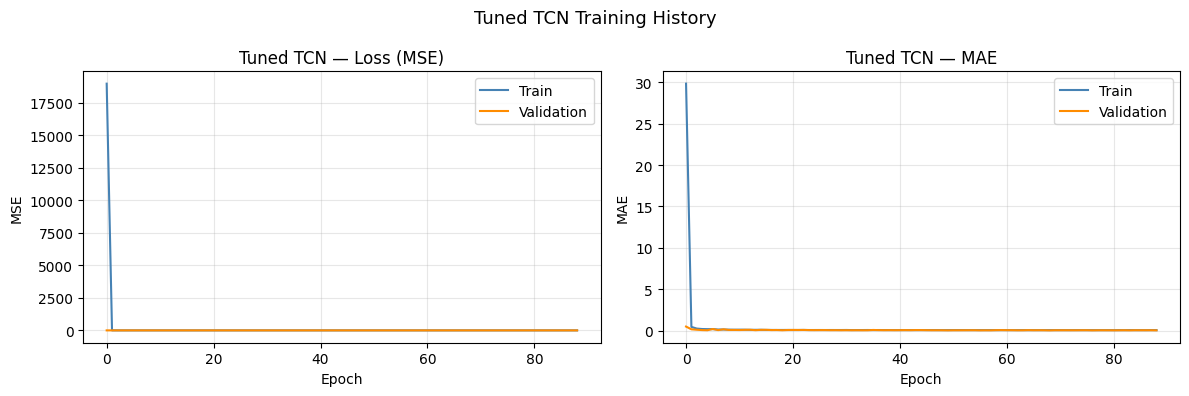

In [ ]:
X_trainval = np.vstack([X_train, X_val])
y_trainval  = np.concatenate([y_train, y_val])
print(f'Combined Train+Val sequences: {X_trainval.shape}')

best_tcn = tuner.hypermodel.build(best_hps)

tuned_callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1)
]

split_idx = int(len(X_trainval) * 0.9)

X_final_train = X_trainval[:split_idx]
y_final_train = y_trainval[:split_idx]
X_final_val   = X_trainval[split_idx:]
y_final_val   = y_trainval[split_idx:]

tuned_history = best_tcn.fit(
    X_final_train, y_final_train,
    validation_data=(X_final_val, y_final_val),
    epochs=200,
    batch_size=32,
    callbacks=tuned_callbacks,
    shuffle=False,
    verbose=1
)

print(f'\nTuned TCN stopped at epoch: {len(tuned_history.history["loss"])}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(tuned_history.history['loss'],     label='Train',      color='steelblue')
axes[0].plot(tuned_history.history['val_loss'], label='Validation', color='darkorange')
axes[0].set_title('Tuned TCN — Loss (MSE)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(tuned_history.history['mae'],     label='Train',      color='steelblue')
axes[1].plot(tuned_history.history['val_mae'], label='Validation', color='darkorange')
axes[1].set_title('Tuned TCN — MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Tuned TCN Training History', fontsize=13)
plt.tight_layout()
plt.savefig('tcn_tuned_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
best_tcn.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 24, 4)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_tuned (TCN)                 │ (None, 128)            │       725,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,175,749 (8.30 MB)

 Trainable params: 725,249 (2.77 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,450,500 (5.53 MB)


Tuned TCN stopped at epoch: 89
First epoch train loss: 18960.703125
First epoch val loss: 0.278076708316803
Final train loss: 0.012987092137336731
Final val loss: 0.005807704292237759
Final train mae: 0.0866648331284523
Final val mae: 0.06161496788263321


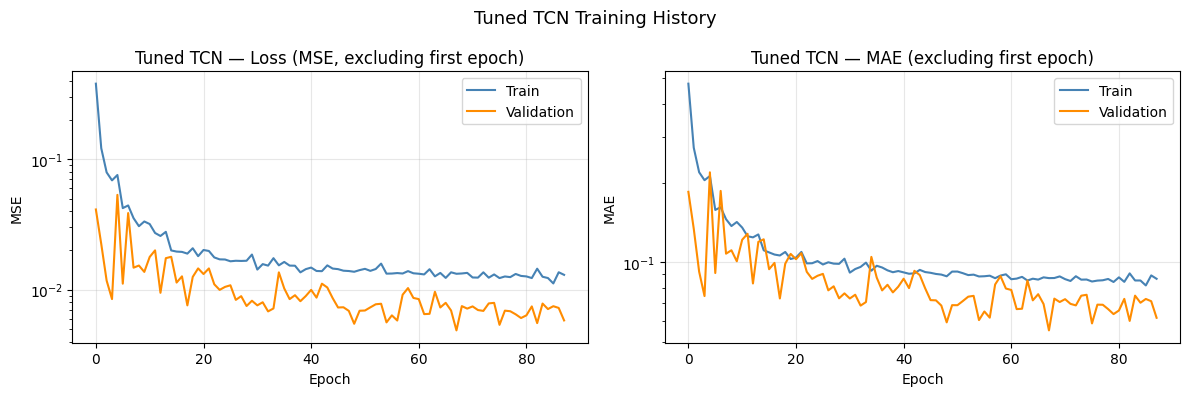

In [ ]:
print(f'\nTuned TCN stopped at epoch: {len(tuned_history.history["loss"])}')
print("First epoch train loss:", tuned_history.history['loss'][0])
print("First epoch val loss:", tuned_history.history['val_loss'][0])
print("Final train loss:", tuned_history.history['loss'][-1])
print("Final val loss:", tuned_history.history['val_loss'][-1])
print("Final train mae:", tuned_history.history['mae'][-1])
print("Final val mae:", tuned_history.history['val_mae'][-1])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(tuned_history.history['loss'][1:], label='Train', color='steelblue')
axes[0].plot(tuned_history.history['val_loss'][1:], label='Validation', color='darkorange')
axes[0].set_title('Tuned TCN — Loss (MSE, excluding first epoch)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].set_yscale('log')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(tuned_history.history['mae'][1:], label='Train', color='steelblue')
axes[1].plot(tuned_history.history['val_mae'][1:], label='Validation', color='darkorange')
axes[1].set_title('Tuned TCN — MAE (excluding first epoch)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Tuned TCN Training History', fontsize=13)
plt.tight_layout()
plt.show()


Tuned TCN stopped at epoch: 89
First epoch train loss: 18960.703125
First epoch val loss: 0.278076708316803
Final train loss: 0.012987092137336731
Final val loss: 0.005807704292237759
Final train mae: 0.0866648331284523
Final val mae: 0.06161496788263321


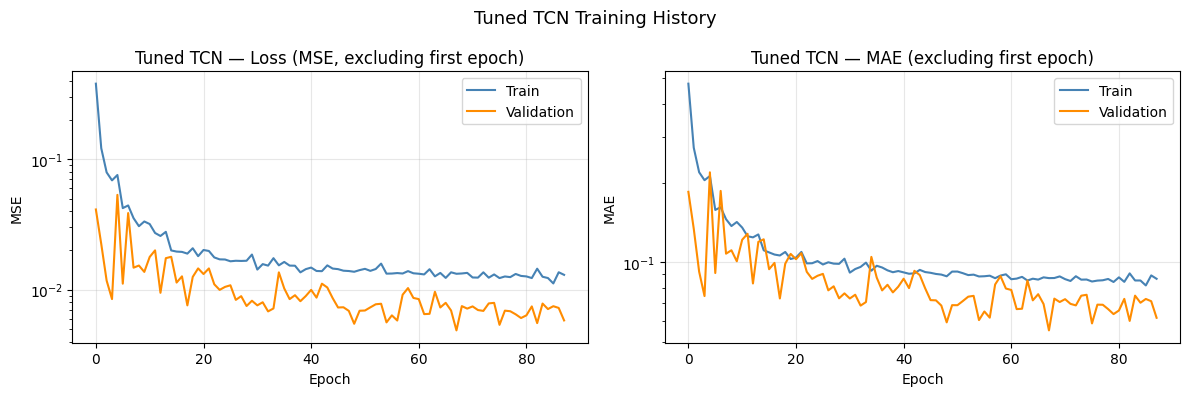

In [ ]:
print(f'\nTuned TCN stopped at epoch: {len(tuned_history.history["loss"])}')
print("First epoch train loss:", tuned_history.history['loss'][0])
print("First epoch val loss:", tuned_history.history['val_loss'][0])
print("Final train loss:", tuned_history.history['loss'][-1])
print("Final val loss:", tuned_history.history['val_loss'][-1])
print("Final train mae:", tuned_history.history['mae'][-1])
print("Final val mae:", tuned_history.history['val_mae'][-1])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(tuned_history.history['loss'][1:], label='Train', color='steelblue')
axes[0].plot(tuned_history.history['val_loss'][1:], label='Validation', color='darkorange')
axes[0].set_title('Tuned TCN — Loss (MSE, excluding first epoch)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].set_yscale('log')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(tuned_history.history['mae'][1:], label='Train', color='steelblue')
axes[1].plot(tuned_history.history['val_mae'][1:], label='Validation', color='darkorange')
axes[1].set_title('Tuned TCN — MAE (excluding first epoch)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Tuned TCN Training History', fontsize=13)
plt.tight_layout()
plt.show()

# Evaluate on Test Set
- **RMSE** — penalises large errors; sensitive to outliers
- **MAE** — median-type error; more robust to extremes
- **MAPE** — relative percentage error; scale-independent
- **R²** — proportion of variance explained; 1 = perfect, 0 = mean baseline
- **NSE** — Nash-Sutcliffe Efficiency; hydrological standard; <0 = worse than mean

In [ ]:
def inverse_transform_target(y_normalised, scaler): # transform them back using the scaler
    return scaler.inverse_transform(y_normalised.reshape(-1, 1)).flatten()

In [ ]:
# calculate the matrice
def compute_all_metrics(y_true, y_pred, label=''):
    rmse   = np.sqrt(mean_squared_error(y_true, y_pred))
    mae    = mean_absolute_error(y_true, y_pred)
    mape   = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    r2     = r2_score(y_true, y_pred)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    nse    = 1 - (ss_res / ss_tot)
    print(f'\n  {"-"*35}')
    print(f'  {label}')
    print(f'  {"-"*35}')
    print(f'  RMSE (m):  {rmse:.4f}')
    print(f'  MAE  (m):  {mae:.4f}')
    print(f'  MAPE (%):  {mape:.4f}')
    print(f'  R2:        {r2:.4f}')
    print(f'  NSE:       {nse:.4f}')
    return {'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2, 'NSE': nse}


In [ ]:
# Baseline TCN predictions
baseline_pred_norm = baseline_tcn.predict(X_test).flatten()
y_test_inv         = inverse_transform_target(y_test, scaler_target)
baseline_pred_inv  = inverse_transform_target(baseline_pred_norm, scaler_target)
baseline_metrics   = compute_all_metrics(y_test_inv, baseline_pred_inv, 'BASELINE TCN — Test Set')

# Tuned TCN predictions
tuned_pred_norm = best_tcn.predict(X_test).flatten()
tuned_pred_inv  = inverse_transform_target(tuned_pred_norm, scaler_target)
tuned_metrics   = compute_all_metrics(y_test_inv, tuned_pred_inv, 'TUNED TCN — Test Set')

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step 

  -----------------------------------
  BASELINE TCN — Test Set
  -----------------------------------
  RMSE (m):  5.2988
  MAE  (m):  4.2803
  MAPE (%):  6.4221
  R2:        -0.4615
  NSE:       -0.4615
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step

  -----------------------------------
  TUNED TCN — Test Set
  -----------------------------------
  RMSE (m):  2.9366
  MAE  (m):  2.3952
  MAPE (%):  3.5738
  R2:        0.5511
  NSE:       0.5511


##Forecast Visualisation
2015-2023

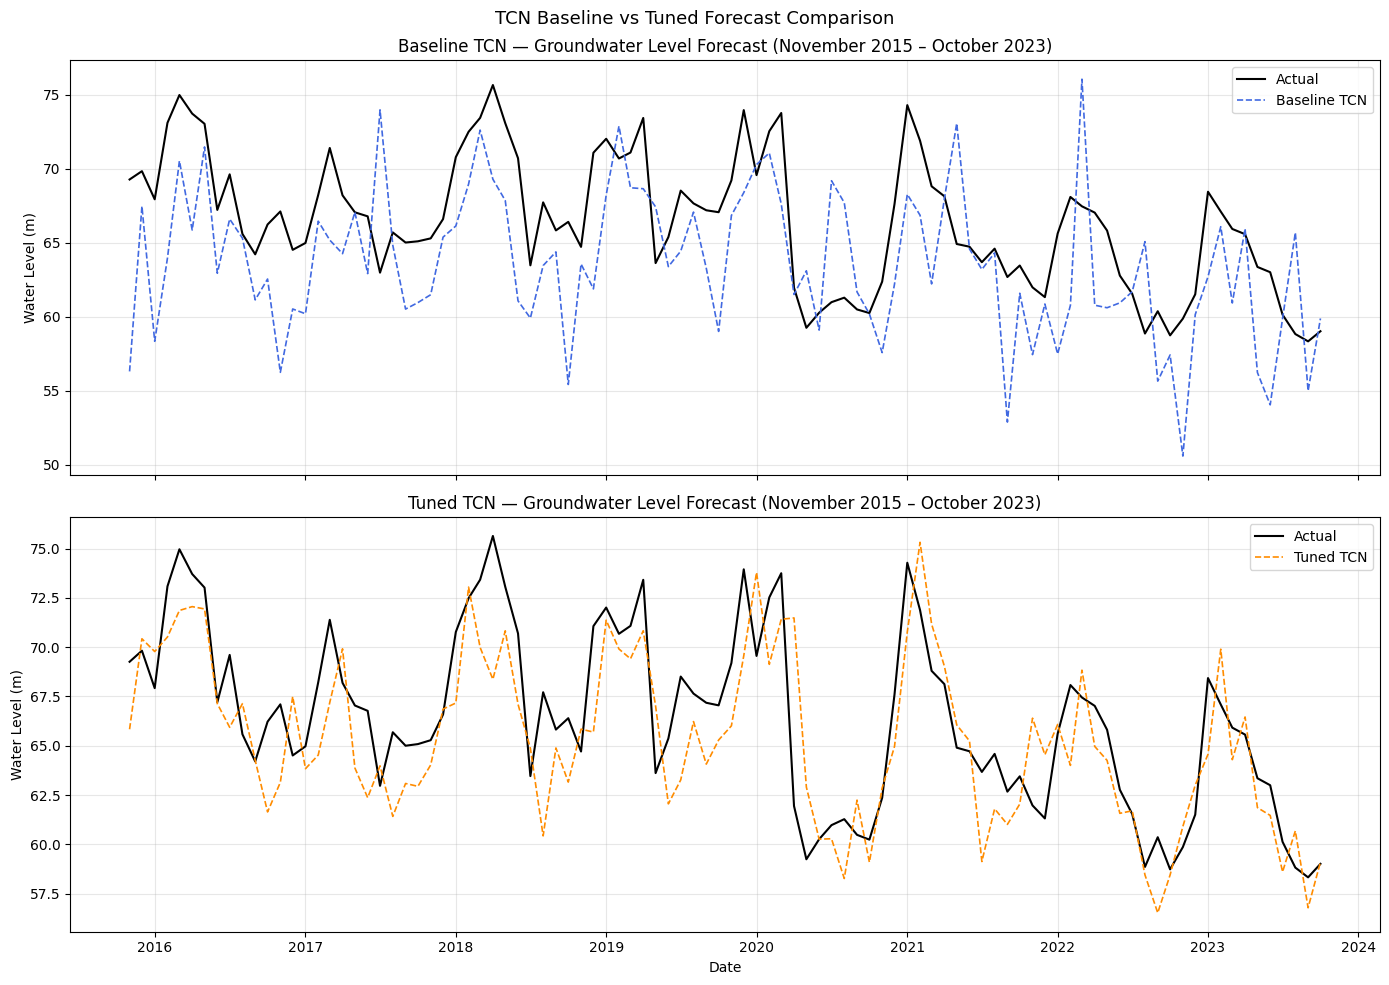

In [ ]:
# Reconstruct test dates — accounting for the lookback buffer
test_dates = test_df.index

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for ax, preds, title, colour in zip(
    axes,
    [baseline_pred_inv, tuned_pred_inv],
    ['Baseline TCN', 'Tuned TCN'],
    ['royalblue', 'darkorange']
):
    ax.plot(test_dates, y_test_inv, label='Actual', color='black', linewidth=1.5)
    ax.plot(test_dates, preds, label=title, color=colour, linestyle='--', linewidth=1.2)
    ax.set_title(f'{title} — Groundwater Level Forecast (November 2015 – October 2023)')
    ax.set_ylabel('Water Level (m)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.xlabel('Date')
plt.suptitle('TCN Baseline vs Tuned Forecast Comparison', fontsize=13)
plt.tight_layout()
plt.savefig('tcn_forecast_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

##Residual Analysis — Tuned TCN


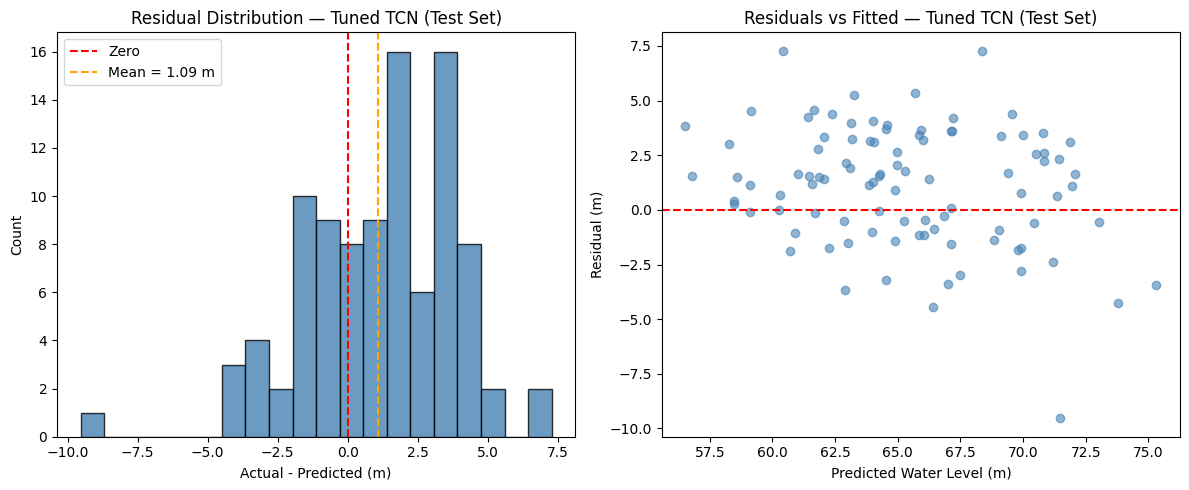


Residual statistics:
  Mean:   +1.0921 m  (close to 0 = unbiased)
  Std:    2.7260 m
  Min:    -9.5359 m
  Max:    7.2832 m


In [ ]:
residuals = y_test_inv - tuned_pred_inv

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Residual histogram
axes[0].hist(residuals, bins=20, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(0,                color='red',    linestyle='--', label='Zero')
axes[0].axvline(residuals.mean(), color='orange', linestyle='--',
                label=f'Mean = {residuals.mean():.2f} m')
axes[0].set_title('Residual Distribution — Tuned TCN (Test Set)')
axes[0].set_xlabel('Actual - Predicted (m)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Right: Residuals vs Fitted
axes[1].scatter(tuned_pred_inv, residuals, alpha=0.6, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuals vs Fitted — Tuned TCN (Test Set)')
axes[1].set_xlabel('Predicted Water Level (m)')
axes[1].set_ylabel('Residual (m)')

plt.tight_layout()
plt.savefig('tcn_residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nResidual statistics:')
print(f'  Mean:   {residuals.mean():+.4f} m  (close to 0 = unbiased)')
print(f'  Std:    {residuals.std():.4f} m')
print(f'  Min:    {residuals.min():.4f} m')
print(f'  Max:    {residuals.max():.4f} m')

## Peak Error Analysis
Evaluates whether the model systematically underperforms during high groundwater events (≥90th percentile) — particularly relevant for flood risk management applications.

In [ ]:
p90_threshold = np.percentile(y_test_inv, 90)
peak_mask     = y_test_inv >= p90_threshold

peak_rmse      = np.sqrt(mean_squared_error(y_test_inv[peak_mask], tuned_pred_inv[peak_mask]))
avg_bias_peaks = np.mean(tuned_pred_inv[peak_mask] - y_test_inv[peak_mask])

print(f'Peak Error Analysis (>=90th percentile, threshold = {p90_threshold:.2f} m):')
print(f'  Peak RMSE:    {peak_rmse:.2f} m')
print(f'  Average Bias: {avg_bias_peaks:+.2f} m  ({"over-prediction" if avg_bias_peaks > 0 else "under-prediction"})')

Peak Error Analysis (>=90th percentile, threshold = 73.04 m):
  Peak RMSE:    3.64 m
  Average Bias: -3.31 m  (under-prediction)


# Hugging Face connection

In [ ]:
import os
import json
import shutil
import joblib
from pathlib import Path
from huggingface_hub import HfApi, create_repo

from google.colab import userdata

HF_USERNAME = 'kozy9'
REPO_NAME   = 'GWTCN'
HF_TOKEN    = userdata.get('Huggingface')  # your write token

REPO_ID   = f'{HF_USERNAME}/{REPO_NAME}'
LOCAL_DIR = Path('hf_upload_tcn')
LOCAL_DIR.mkdir(exist_ok=True)

print(f'Preparing upload to: https://huggingface.co/{REPO_ID}')

Preparing upload to: https://huggingface.co/kozy9/GWTCN


In [ ]:
# ── 1. Save best model & scalers
# Save the tuned TCN model directly (no checkpoint file to copy — save fresh)
best_tcn.save(LOCAL_DIR / 'tcn_model.keras')
print(f'Model saved  →  {LOCAL_DIR}/tcn_model.keras')

# Save scalers
joblib.dump(scaler_features, LOCAL_DIR / 'scaler_features.pkl')
joblib.dump(scaler_target,   LOCAL_DIR / 'scaler_target.pkl')
print(f'Scalers saved →  scaler_features.pkl, scaler_target.pkl')

Model saved  →  hf_upload_tcn/tcn_model.keras
Scalers saved →  scaler_features.pkl, scaler_target.pkl


In [ ]:
# ── 2. Save model config & metrics ────────────────────────────────────────────
config = {
    'model_type'  : 'TCN',
    'architecture': f'TCN(nb_filters={best_hps.get("nb_filters")}, kernel_size={best_hps.get("kernel_size")}, dilations={best_dilations}) → Dense(1)',
    'framework'   : 'TensorFlow/Keras (keras-tcn)',
    'task'        : 'Single-step monthly groundwater level forecasting',
    'features'    : FEATURES,
    'target'      : TARGET,
    'lookback_months': LOOKBACK,
    'horizon_months' : HORIZON,
    'tuning': {
        'method'  : 'Bayesian Optimisation (Keras Tuner)',
        'n_trials': 20,
        'best_config': {
            'nb_filters'      : int(best_hps.get('nb_filters')),
            'kernel_size'     : int(best_hps.get('kernel_size')),
            'dilations'       : best_dilations,
            'dropout_rate'    : float(best_hps.get('dropout_rate')),
            'learning_rate'   : float(best_hps.get('learning_rate')),
            'receptive_field' : int(best_rf),
        }
    },
    'data_splits': {
        'train'     : {'start': str(train_df.index.min().date()), 'end': str(train_df.index.max().date()), 'n_months': len(train_df)},
        'validation': {'start': str(val_df.index.min().date()),   'end': str(val_df.index.max().date()),   'n_months': len(val_df)},
        'test'      : {'start': str(test_df.index.min().date()),  'end': str(test_df.index.max().date()),  'n_months': len(test_df)},
    },
    'test_metrics': {
        'RMSE'    : round(float(tuned_metrics['RMSE']),  4),
        'MAE'     : round(float(tuned_metrics['MAE']),   4),
        'MAPE_pct': round(float(tuned_metrics['MAPE']),  4),
        'R2'      : round(float(tuned_metrics['R2']),    4),
        'NSE'     : round(float(tuned_metrics['NSE']),   4),
    },
    'notes': 'Scaler fitted on train only. Oracle exog assumption — contemporaneous met vars used at forecast time.'
}

config_path = LOCAL_DIR / 'model_config.json'
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)

print(f'Config saved →  {config_path}')
print(json.dumps(config, indent=2))

Config saved →  hf_upload_tcn/model_config.json
{
  "model_type": "TCN",
  "architecture": "TCN(nb_filters=128, kernel_size=4, dilations=[1, 2, 4, 8, 16, 32]) \u2192 Dense(1)",
  "framework": "TensorFlow/Keras (keras-tcn)",
  "task": "Single-step monthly groundwater level forecasting",
  "features": [
    "water_level",
    "temperature",
    "precipitation",
    "wind_speed"
  ],
  "target": "water_level",
  "lookback_months": 24,
  "horizon_months": 1,
  "tuning": {
    "method": "Bayesian Optimisation (Keras Tuner)",
    "n_trials": 20,
    "best_config": {
      "nb_filters": 128,
      "kernel_size": 4,
      "dilations": [
        1,
        2,
        4,
        8,
        16,
        32
      ],
      "dropout_rate": 0.1,
      "learning_rate": 0.01,
      "receptive_field": 379
    }
  },
  "data_splits": {
    "train": {
      "start": "1944-01-01",
      "end": "2007-10-01",
      "n_months": 766
    },
    "validation": {
      "start": "2007-11-01",
      "end": "2015-10-0

In [ ]:
# ── 3. Write inference.py ─────────────────────────────────────────────────────
inference_code = '''
"""
inference.py — TCN Groundwater Level Forecasting
=================================================
Usage
-----
    from inference import load_model, forecast
    model, scaler_features, scaler_target = load_model()
    prediction = forecast(model, scaler_features, scaler_target, X_window)
"""

import json
import joblib
import numpy as np
import pandas as pd
from pathlib import Path
from tensorflow.keras.models import load_model as keras_load

MODEL_PATH          = Path(__file__).parent / "tcn_model.keras"
SCALER_FEATURES_PATH = Path(__file__).parent / "scaler_features.pkl"
SCALER_TARGET_PATH  = Path(__file__).parent / "scaler_target.pkl"
CONFIG_PATH         = Path(__file__).parent / "model_config.json"


def load_model():
    """Load the TCN model and both scalers."""
    model           = keras_load(MODEL_PATH)
    scaler_features = joblib.load(SCALER_FEATURES_PATH)
    scaler_target   = joblib.load(SCALER_TARGET_PATH)
    print("TCN model and scalers loaded.")
    return model, scaler_features, scaler_target


def load_config():
    with open(CONFIG_PATH) as f:
        return json.load(f)


def forecast(model, scaler_features, scaler_target, X_window: pd.DataFrame):
    """
    Predict the next month\'s groundwater level.

    Parameters
    ----------
    model           : loaded Keras TCN model
    scaler_features : fitted MinMaxScaler for all 4 input features
    scaler_target   : fitted MinMaxScaler for water_level target
    X_window        : DataFrame with columns [water_level, temperature,
                      precipitation, wind_speed] and exactly 24 rows
                      (the lookback window)

    Returns
    -------
    prediction : float — forecasted water level in original units (m)
    """
    cfg      = load_config()
    required = cfg[\'features\']
    lookback = cfg[\'lookback_months\']

    missing = [c for c in required if c not in X_window.columns]
    if missing:
        raise ValueError(f"X_window is missing columns: {missing}")
    if len(X_window) != lookback:
        raise ValueError(f"X_window must have {lookback} rows, got {len(X_window)}")

    X_scaled   = scaler_features.transform(X_window[required])
    X_input    = X_scaled.reshape(1, lookback, len(required))

    y_scaled   = model.predict(X_input, verbose=0).flatten()
    prediction = scaler_target.inverse_transform(y_scaled.reshape(-1, 1)).flatten()[0]

    return float(prediction)


if __name__ == "__main__":
    model, scaler_features, scaler_target = load_model()
    cfg = load_config()
    print(f"Model: {cfg[\'architecture\']}")
    print(f"Test RMSE: {cfg[\'test_metrics\'][\'RMSE\']} m")

    # Dummy window — replace with real data
    dummy = pd.DataFrame({
        \'water_level\'  : np.random.uniform(60, 75, 24),
        \'temperature\'  : np.random.uniform(3, 15, 24),
        \'precipitation\': np.random.uniform(20, 120, 24),
        \'wind_speed\'   : np.random.uniform(10, 25, 24),
    })
    pred = forecast(model, scaler_features, scaler_target, dummy)
    print(f"\\nForecast (next month): {pred:.4f} m")
'''

inference_path = LOCAL_DIR / 'inference.py'
inference_path.write_text(inference_code.strip())
print(f'Inference script saved →  {inference_path}')

Inference script saved →  hf_upload_tcn/inference.py


In [ ]:
# ── 4. Write README / model card ──────────────────────────────────────────────
m  = config['test_metrics']
hp = config['tuning']['best_config']

readme = f"""---
license: mit
tags:
  - time-series
  - forecasting
  - tcn
  - hydrology
  - groundwater
---

# TCN Groundwater Level Forecasting — UK

A tuned Temporal Convolutional Network (TCN) for single-step monthly groundwater
level forecasting using meteorological variables as exogenous inputs.

## Model Details

| Parameter | Value |
|---|---|
| Architecture | {config['architecture']} |
| Framework | TensorFlow / Keras (keras-tcn) |
| Task | Single-step monthly forecasting |
| Lookback window | {config['lookback_months']} months |
| Input features | water_level, temperature, precipitation, wind_speed |
| Tuning method | Bayesian Optimisation (Keras Tuner, {config['tuning']['n_trials']} trials) |

## Data Splits

| Split | Period | Months |
|---|---|---|
| Training | {config['data_splits']['train']['start']} → {config['data_splits']['train']['end']} | {config['data_splits']['train']['n_months']} |
| Validation | {config['data_splits']['validation']['start']} → {config['data_splits']['validation']['end']} | {config['data_splits']['validation']['n_months']} |
| Test | {config['data_splits']['test']['start']} → {config['data_splits']['test']['end']} | {config['data_splits']['test']['n_months']} |

## Best Hyperparameters

| Parameter | Value |
|---|---|
| nb_filters | {hp['nb_filters']} |
| kernel_size | {hp['kernel_size']} |
| dilations | {hp['dilations']} |
| dropout_rate | {hp['dropout_rate']} |
| learning_rate | {hp['learning_rate']:.6f} |
| Receptive field | {hp['receptive_field']} months |

## Test Set Performance

| Metric | Value |
|---|---|
| RMSE | {m['RMSE']} m |
| MAE | {m['MAE']} m |
| MAPE | {m['MAPE_pct']}% |
| R² | {m['R2']} |
| NSE | {m['NSE']} |

> This model is part of a benchmark study comparing SARIMAX, LSTM, and TCN
> for UK groundwater level forecasting.

## Important Note

Contemporaneous meteorological variables are used as inputs at forecast time
(oracle assumption). Future met values are treated as known — consistent with
the experimental setup used across all models in this study.

## Repository Contents
```
├── tcn_model.keras        # Trained Keras TCN model
├── scaler_features.pkl    # Feature scaler (MinMaxScaler, fit on train only)
├── scaler_target.pkl      # Target scaler (MinMaxScaler, for inverse transform)
├── model_config.json      # Config, hyperparameters & metrics
├── inference.py           # Load model & generate forecasts
└── README.md              # This file
```

## Quick Start
```python
from huggingface_hub import hf_hub_download
from tensorflow.keras.models import load_model
import joblib, pandas as pd, numpy as np

model           = load_model(hf_hub_download('{REPO_ID}', 'tcn_model.keras'))
scaler_features = joblib.load(hf_hub_download('{REPO_ID}', 'scaler_features.pkl'))
scaler_target   = joblib.load(hf_hub_download('{REPO_ID}', 'scaler_target.pkl'))

# Provide a 24-month window of features
X_window = pd.DataFrame({{
    'water_level'  : [...],   # 24 values
    'temperature'  : [...],
    'precipitation': [...],
    'wind_speed'   : [...],
}})

X_scaled = scaler_features.transform(X_window)
X_input  = X_scaled.reshape(1, 24, 4)
y_scaled = model.predict(X_input)
pred     = scaler_target.inverse_transform(y_scaled)[0][0]
print(f'Next month forecast: {{pred:.2f}} m')
```
"""

readme_path = LOCAL_DIR / 'README.md'
readme_path.write_text(readme)
print(f'Model card saved →  {readme_path}')

Model card saved →  hf_upload_tcn/README.md


In [ ]:
# ── 5. Copy figures ───────────────────────────────────────────────────────────
for fig in Path('.').glob('tcn_*.png'):
    shutil.copy(fig, LOCAL_DIR / fig.name)
    print(f'Copied {fig.name}')

print('\nFiles ready for upload:')
for f in sorted(LOCAL_DIR.iterdir()):
    print(f'  {f.name}  ({f.stat().st_size / 1024:.1f} KB)')# ── 6. Create repo & upload ───────────────────────────────────────────────────
api = HfApi()

create_repo(
    repo_id   = REPO_ID,
    token     = HF_TOKEN,
    repo_type = 'model',
    exist_ok  = True,
    private   = False,
)
print(f'Repo ready: https://huggingface.co/{REPO_ID}')

api.upload_folder(
    folder_path    = str(LOCAL_DIR),
    repo_id        = REPO_ID,
    repo_type      = 'model',
    token          = HF_TOKEN,
    commit_message = f'Upload TCN — test RMSE {config["test_metrics"]["RMSE"]} m  R² {config["test_metrics"]["R2"]}',
)

print(f'\nUpload complete!')
print(f'View at: https://huggingface.co/{REPO_ID}')

Copied tcn_forecast_comparison.png
Copied tcn_baseline_training_history.png
Copied tcn_tuned_training_history.png
Copied tcn_residual_analysis.png

Files ready for upload:
  README.md  (2.8 KB)
  inference.py  (3.0 KB)
  model_config.json  (1.3 KB)
  scaler_features.pkl  (1.1 KB)
  scaler_target.pkl  (1.0 KB)
  tcn_baseline_training_history.png  (64.6 KB)
  tcn_forecast_comparison.png  (384.3 KB)
  tcn_model.keras  (8661.1 KB)
  tcn_residual_analysis.png  (84.2 KB)
  tcn_tuned_training_history.png  (54.3 KB)
Repo ready: https://huggingface.co/kozy9/GWTCN


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(



Upload complete!
View at: https://huggingface.co/kozy9/GWTCN


# RISDUAL GRAPH
will generate it using hugging face so I do not need to re run the code

In [3]:
!pip install keras-tcn keras-tuner


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 4.3 MB/s eta 0:00:00


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step


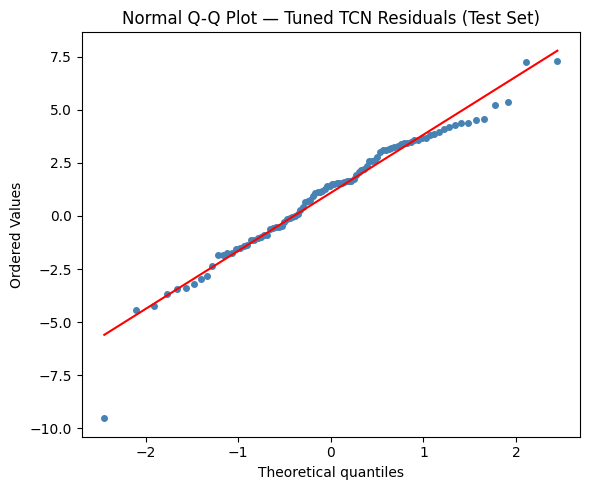

In [6]:
from huggingface_hub import hf_hub_download
from tensorflow.keras.models import load_model
import joblib, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from tcn import TCN # Import TCN for custom object loading

# Load model and scalers
model           = load_model(hf_hub_download('kozy9/GWTCN', 'tcn_model.keras'))

scaler_features = joblib.load(hf_hub_download('kozy9/GWTCN', 'scaler_features.pkl'))
scaler_target   = joblib.load(hf_hub_download('kozy9/GWTCN', 'scaler_target.pkl'))

# Load CSVs
train_df = pd.read_csv('uk_train.csv',    index_col='date', parse_dates=True)
val_df   = pd.read_csv('uk_validate.csv', index_col='date', parse_dates=True)
test_df  = pd.read_csv('uk_test.csv',     index_col='date', parse_dates=True)

FEATURES = ['water_level', 'temperature', 'precipitation', 'wind_speed']
LOOKBACK  = 24

# Scale
train_arr = scaler_features.transform(train_df[FEATURES])
val_arr   = scaler_features.transform(val_df[FEATURES])
test_arr  = scaler_features.transform(test_df[FEATURES])

# Build test sequences with lookback buffer
test_input = np.vstack([val_arr[-LOOKBACK:], test_arr])

def create_sequences(data, lookback=24):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i, :])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_test, y_test = create_sequences(test_input)

# Predict and inverse transform
y_pred_scaled = model.predict(X_test)
y_pred_inv    = scaler_target.inverse_transform(y_pred_scaled).flatten()
y_test_inv    = scaler_target.inverse_transform(y_test.reshape(-1,1)).flatten()

# Residuals
residuals = y_test_inv - y_pred_inv

# Q-Q plot
fig, ax = plt.subplots(figsize=(6, 5))
stats.probplot(residuals, dist="norm", plot=ax)
ax.set_title('Normal Q-Q Plot — Tuned TCN Residuals (Test Set)')
ax.get_lines()[0].set(color='steelblue', markersize=4)
ax.get_lines()[1].set(color='red')
plt.tight_layout()
plt.savefig('tcn_qq_plot.png', dpi=150)
plt.show()